# Training — P1 baselines + Pipeline A on the local logs

Multi-frame training over the converted py123d logs (split **by log**: last one held out for validation — frames within a log are correlated, a per-frame split would leak). All implementation lives in the `.py` modules; this notebook only wires them:

| block | module |
|---|---|
| targets + loss + loop | `train.py` (`TargetEncoder`, `CenterPointLoss`, `train_model`) |
| models | `network.py` (`LidarOnlyDetector`, `PipelineA/B/C`) |
| stereo input cache | `data.py` (`precompute_stereo_inputs`) |
| decode + distance-AP | `evaluation.py` (`CenterPointDecoder`, `evaluate_model`) |

## 1. Imports

In [ ]:
import os
from pathlib import Path
import data  # noqa: F401  (repo module; also used below)

# Point py123d at the repo-local roots (now symlinks -> the external Volume where
# the dataset lives). setdefault respects the env vars if already exported.
_REPO = Path(data.__file__).resolve().parent
os.environ.setdefault("PY123D_DATA_ROOT", str(_REPO / "data"))
os.environ.setdefault("KITTI360_DATA_ROOT", str(_REPO / "KITTI-360"))

import matplotlib.pyplot as plt
import torch

import data
import globals as G
import utils
from data import (Py123dDataset, StereoSGBMConfig,
                  precompute_stereo_inputs, stereo_cache_root)
import igev_matcher  # registers the IGEV learned matcher (lazy)
from evaluation import (CenterPointDecoder, compare_reports, evaluate_model,
                        load_report, print_ap_report, save_report)
from network import (CameraOnlyDetector, LidarOnlyDetector, PipelineA,
                     PipelineB, PipelineC, lidar_points)
from train import TargetEncoder, set_seed, train_model, validate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

## 2. Globals

In [ ]:
print("grid:", G.GRID_SIZE, "| x:", G.X_RANGE, "| y:", G.Y_RANGE)
print("classes:", G.CLASSES)

# --- run configuration -------------------------------------------------
# MODEL: "lidar" | "camera" (single-sensor baselines)
#        "pipeline_a" (concat-conv fusion) | "pipeline_b" (+ painted lidar)
#        "pipeline_c" (cross-attention fusion)
MODEL = "pipeline_a"
EPOCHS = 4
LR = 1e-3
ACCUM = 4  # frames per optimizer step (batch-1 + accumulation)
SEED = 0   # python/numpy/torch/CUDA RNGs (weight init, shuffling)

# Split is now by DRIVE via the converted py123d splits (no in-notebook split):
#   train = kitti360_train  -> drives 0003 + 0007 + 0009
#   val   = kitti360_val    -> drive 0010 (held-out, rich in every class)

# camera stem (camera / pipeline_* only): "efficientnet" trains a ~1M-param CNN
# from scratch (weak); "yolo26" uses a COCO-pretrained backbone. FREEZE keeps it
# fixed so only the head/BEV/context train — the strong first baseline to try.
CAMERA_BACKBONE = "yolo26"  # "efficientnet" | "yolo26"
FREEZE_BACKBONE = True

# camera-branch DEPTH source: "igev" = dense learned stereo (recommended) via the
# stereo_inputs_igev cache; "sgbm" = classic sparse block matching. Training only
# READS the cache (no matcher at runtime).
MATCHER = "igev"  # "igev" | "sgbm"

tag = "" if MODEL == "lidar" else f"_{CAMERA_BACKBONE}_{MATCHER}"
CKPT = f"checkpoints/{MODEL}{tag}.pt"   # best-val weights (train_model writes it)
RESULTS = f"results/{MODEL}{tag}.json"  # eval report (§7 writes; §9 compares)

set_seed(SEED)  # reproducible runs (not bit-deterministic: CUDA atomics)

## 3. Data — train/val by drive

`train = kitti360_train` (drives **0003 + 0007 + 0009**) · `val = kitti360_val` (drive **0010**, held out). Splitting by whole drive is the only leak-free split (consecutive frames of one drive are strongly correlated). Drive 0009 was added specifically because 0003/0007 are the dataset's two *poorest* drives for PERSON/TWO_WHEELER; 0010 is rich in every class and makes a proper validation set.

In [ ]:
# Split by DRIVE: train = kitti360_train (0003+0007+0009), val = kitti360_val (0010).
# Frames within a drive are correlated, so holding out a whole drive is the only
# leak-free split — and 0010 now carries every class (VEHICLE/PERSON/TWO_WHEELER/
# TRAFFIC_SIGN/GENERIC_OBJECT, + the rare TRAIN/TRAFFIC_LIGHT).
train_ds = Py123dDataset(split_names=["kitti360_train"])
val_ds = Py123dDataset(split_names=["kitti360_val"])
train_frames = list(train_ds)
val_frames = list(val_ds)
print(train_ds)
print(val_ds)
print(f"train: {len(train_frames)} frames / {train_ds.scene_count} drives | "
      f"val: {len(val_frames)} frames / {val_ds.scene_count} drives")

## 4. Stereo input cache (one-time, camera training only)

SGBM is ~1–2 s/frame on CPU and never changes, so precompute the camera-branch inputs once (<1 MB/frame, resumable — already-cached frames are skipped). Not needed for the LiDAR-only baseline; expect ~15–25 min for all 784 frames on first run.

In [ ]:
# Depth cache for the chosen MATCHER (stereo_inputs_igev for IGEV), built ONCE for
# BOTH splits. A complete cache makes this a fast no-op (existing frames skipped);
# training then reads it per step with no matcher at runtime. First run on the new
# drive 0009 (~5k frames) is the slow part — IGEV on GPU, budget accordingly.
CACHE_ROOT = stereo_cache_root(train_ds.data_root, matcher=MATCHER)
if MODEL != "lidar":
    if MATCHER != "sgbm":
        igev_matcher.register()  # learned matcher (only builds on a cache miss)
    for _ds in (train_ds, val_ds):
        precompute_stereo_inputs(_ds, cache_root=CACHE_ROOT,
                                 sgbm_cfg=StereoSGBMConfig(matcher=MATCHER))
print("cache root:", CACHE_ROOT)

## 5. Network

In [ ]:
from network import StereoBEVConfig

# camera-branch config: pick the backbone + freeze from §2 (ignored by lidar).
stereo_cfg = StereoBEVConfig(img_backbone=CAMERA_BACKBONE,
                             yolo_freeze=FREEZE_BACKBONE)

if MODEL == "lidar":
    model = LidarOnlyDetector()
    input_fn = lidar_points  # sample -> (N, 4) points
elif MODEL == "camera":
    model = CameraOnlyDetector(stereo_cache_root=CACHE_ROOT,
                               stereo_cfg=stereo_cfg)
    input_fn = None  # consumes the sample itself
else:
    Pipeline = {"pipeline_a": PipelineA, "pipeline_b": PipelineB,
                "pipeline_c": PipelineC}[MODEL]
    model = Pipeline(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg)
    input_fn = None

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"{type(model).__name__}: {trainable:,} trainable" +
      (f" | {frozen:,} frozen ({CAMERA_BACKBONE} backbone)" if frozen else ""))

## 6. Train

In [6]:
history = train_model(model,
                      train_frames,
                      val_frames,
                      input_fn=input_fn,
                      epochs=EPOCHS,
                      lr=LR,
                      accum=ACCUM,
                      ckpt_path=CKPT,
                      device=DEVICE)

/home/leonardo/Desktop/AIRO/stereo-lidar-perception/train.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total, {"heatmap": float(hm_loss), "offset": float(off_loss)}


  epoch 1 step 50/1010 loss 31.999
  epoch 1 step 100/1010 loss 18.842
  epoch 1 step 150/1010 loss 10.430
  epoch 1 step 200/1010 loss 6.457
  epoch 1 step 250/1010 loss 8.738
  epoch 1 step 300/1010 loss 5.006
  epoch 1 step 350/1010 loss 6.535
  epoch 1 step 400/1010 loss 2.827
  epoch 1 step 450/1010 loss 5.284
  epoch 1 step 500/1010 loss 3.904
  epoch 1 step 550/1010 loss 1.826
  epoch 1 step 600/1010 loss 1.471
  epoch 1 step 650/1010 loss 1.226
  epoch 1 step 700/1010 loss 1.423
  epoch 1 step 750/1010 loss 1.131
  epoch 1 step 800/1010 loss 0.889
  epoch 1 step 850/1010 loss 0.881
  epoch 1 step 900/1010 loss 0.786
  epoch 1 step 950/1010 loss 4.201
  epoch 1 step 1000/1010 loss 1.078
epoch 1/2  train 8.066  val 1.896
  new best val — checkpoint saved → checkpoints/pipeline_a_yolo26_igev.pt
  epoch 2 step 50/1010 loss 1.120
  epoch 2 step 100/1010 loss 0.622
  epoch 2 step 150/1010 loss 2.111
  epoch 2 step 200/1010 loss 0.504
  epoch 2 step 250/1010 loss 2.931
  epoch 2 step 

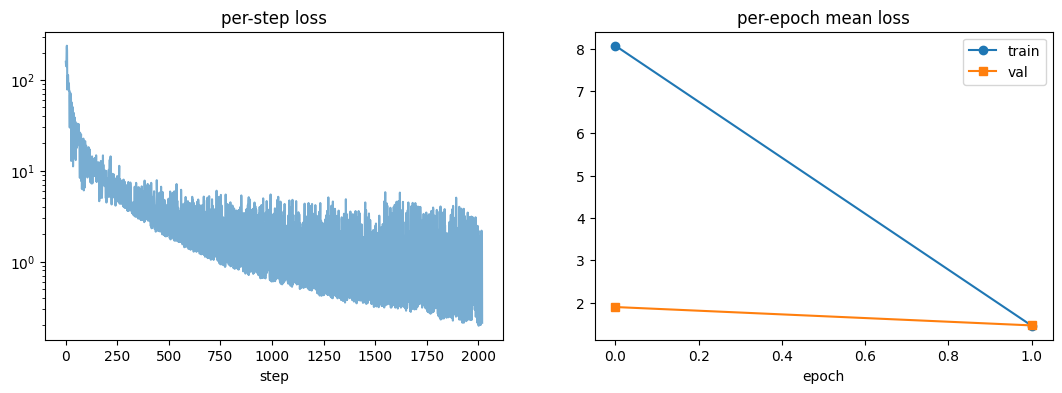

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["steps"], alpha=0.6)
ax[0].set_yscale("log")
ax[0].set_title("per-step loss")
ax[0].set_xlabel("step")
ax[1].plot(history["train"], "o-", label="train")
ax[1].plot(history["val"], "s-", label="val")
ax[1].set_title("per-epoch mean loss")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.show()

## 7. Test — distance-AP on the held-out log

Center-distance (AV2-style bands): a detection is a TP if its centre lands within 0.5/1/2/4 m of an unmatched GT centre of the same class. Loads the best-val checkpoint first.

In [ ]:
model.load_state_dict(torch.load(CKPT, weights_only=True)["model"])
report = evaluate_model(model, val_frames, input_fn=input_fn, device=DEVICE)
print_ap_report(report)
save_report(report,
            RESULTS)  # results/<MODEL>.json — reload in §9 to compare runs

In [ ]:
# PR curves + F1-vs-confidence (read the deployment threshold off the peak)
# + confusion matrix (background row = FP, background column = missed GT)
utils.visualize_evaluation(report)

In [ ]:
# qualitative check: decoded detections vs GT on a few val frames
model.eval()
decoder = CenterPointDecoder(score_threshold=0.2)
for frame in val_frames[10:151:70]:
    sample = frame.to_stereo_sample()
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)

In [ ]:
# stereo -> BEV diagnostic: does the net SEE objects (panel 1) but fail to PLACE
# them in BEV because the stereo depth is missing/wrong (panel 3) -> empty output
# (panel 4)? Needs full samples (images). Camera / pipeline_a only.
if MODEL != "lidar":
    for frame in val_frames[10:151:60]:
        sample = frame.to_stereo_sample()  # full sample (load_images=True)
        utils.visualize_stereo_bev_diagnostic(model,
                                              sample,
                                              device=DEVICE,
                                              score_threshold=0.15)
else:
    print("stereo diagnostic is camera/fusion only (needs the stereo branch)")

## 8. Branch contribution (fused runs only)

Two complementary measurements:

1. **Baselines table** — train `lidar`, `camera`, `pipeline_a` with this same notebook (same split/seed/epochs) and compare their AP tables. Fusion's contribution = `pipeline_a` − best single-sensor baseline.
2. **Branch dropout** — evaluate the *trained* fused model with one branch zeroed (`drop_branch`): the AP drop is that branch's marginal contribution inside the fusion. Caveat: a zeroed map is a "silent sensor" the fusion conv never saw in training — it bounds the contribution, it's not a retrained baseline.

In [ ]:
if MODEL == "pipeline_a":
    for drop in (None, "camera", "lidar"):
        model.drop_branch = drop
        rep = evaluate_model(model,
                             val_frames,
                             input_fn=input_fn,
                             device=DEVICE)
        print(f"\n=== drop_branch = {drop} "
              f"(mAP {rep['mAP']:.3f}) {'=' * 30}")
        print_ap_report(rep)
    model.drop_branch = None  # always reset
else:
    print(
        "single-sensor run — train MODEL='pipeline_a' for the dropout ablation"
    )

## 9. Compare saved approaches

Every §7 run wrote `results/<MODEL>.json`. Load them all back and print one
table — no re-evaluation needed. Run this after you've trained + tested each of
`lidar`, `camera`, `pipeline_a` (same split/seed). The per-class columns are the
mean AP over the 0.5/1/2/4 m thresholds; P/R/F1 are macro at the 2 m operating
point. Fusion's contribution = `pipeline_a` row − best single-sensor row.

In [ ]:
from pathlib import Path

runs = {p.stem: load_report(p) for p in sorted(Path("results").glob("*.json"))}
if runs:
    compare_reports(runs)
else:
    print("no saved reports yet — run §7 for each MODEL first")

## Next

- **Compare pipelines:** run `MODEL` = `"lidar"` → `"camera"` → `"pipeline_a"` → `"pipeline_b"` → `"pipeline_c"` (same split/seed), then §9 loads every `results/*.json` into one AP table. Fusion's contribution = pipeline row − best single-sensor row.
- **Class caveats (5-class unified):** `TRAIN` (~5 boxes, drive 0010 only → never in train) will sit near 0 AP — expected, it is eval-only. `GENERIC_OBJECT` (poles/box/…) and `trafficLight` are excluded. The well-supported classes are VEHICLE / PERSON / TWO_WHEELER / TRAFFIC_SIGN.
- **More data / balance:** add richer drives via `TRAIN_SEQ="… 0000 0006" scripts/get_kitti360.sh` (sizes in the download table); each is 30–45 GB. Keep drive 0010 as the val drive so results stay comparable.
- BEV augmentation (rotation/flip), warm-start the fused run from the baselines, per-range AP bins, and the full CDS metric.